<a href="https://colab.research.google.com/github/goktuggokmen/Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning/blob/main/Derin_%C3%96%C4%9Frenme_Kullanarak_Kripto_Para_Fiyat_Tahmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color='red'>İZMİR DEMOKRASİ ÜNİVERSİTESİ</font>**
# **<font color='red'>MÜHENDİSLİK FAKÜLTESİ</font>**
# **<font color='red'>ELEKTRİK-ELEKTRONİK MÜHENDİSLİĞİ</font>**      
# **<font color='red'>EEM 408 Sayısal Sinyal İşleme Uygulamaları</font>**
# **<font color='red'>Proje Sunumu : Derin Öğrenme Kullanarak Kripto Para Fiyat Tahmini</font>**   
# **<font color='red'>Hazırlayan: Göktuğ Gökmen - 1806102007</font>**   

                    

# **<font color='black'>Problem Tanımı</font>**  


<font color='gray'>Bitcoin, Blockchain (Blok Zinciri) altyapısı üzerine kurulmuş olan en popüler kripto para birimidir. Mevcut şartlarda Kripto Para borsasının en büyük hacmine sahip olan Bitcoin gelecekteki değerinin ne olacağı oldukça merak edilen bir konudur. Bu çalışmada, Bitcoin/USD ve diğer Kripto Coin’lerin tarih öznitelikleri ile değer tahmini yapılacaktır. Çalışmanın amacı, finans sektörü ve ticari işlemler ile yakından ilişkisi olan Bitcoin ve bazı diğer önemli Kripto Coin’lerin fiyat tahmininin gerçekleştirilerek hem kullanıcılara hem de yatırımcılara kısa ve orta vadede seçenekler sunarak, zamanında ve yerinde doğru yatırım yapılmasına yardımcı olmaktır. Çalışmanın yapılmasında Yapay Sinir Ağları (ANN) ve Long Short-Term Memory (LSTM) yapay zekâ yöntemleri kullanılacaktır.</font>


# **<font color='black'>Hedef</font>**  

<font color='gray'>Veri setinde bulunan fiyat, hacim, açılış, yüksek, düşük değerler gibi tüm ticaret özelliklerini kullanarak kripto para birimi fiyatlarını tahmin etmek.</font>

# **<font color='black'>Yöntem</font>**  

<font color='gray'>Bu projede, kripto para birimi fiyatlarını tahmin etmek için uygulayacağımız dört adımlı süreç şu şekilde olacaktır:

<font color='red'>1.</font> Gerçek zamanlı kripto para birimi verilerini alma.

<font color='red'>2.</font> Verileri, eğitim ve test verisi olarak hazırlama.

<font color='red'>3.</font> LSTM sinir ağını kullanarak kripto para biriminin fiyatını tahmin etme.

<font color='red'>4.</font> Tahmin sonuçlarını görselleştirme ve başarı metriklerinin değerlendirilmesi.

# **<font color='black'>Kütüphanelerin Yüklenmesi</font>**  

In [ ]:
%tensorflow_version 2.x
import json
import requests #HTTP kutuphanesi
from keras.models import Sequential #Sequential bir model, her katmanın tam olarak bir giriş tensörüne ve bir çıkış tensörüne sahip olduğu düz bir katman yığını için uygundur.
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


# **<font color='black'>Veri setinin Yüklenmesi ve Düzenlenmesi</font>**

In [ ]:
res = requests.get('https://min-api.cryptocompare.com/data/histoday' + '?fsym=BTC&tsym=USD&limit=500') #500 gunluk BTC/USD verisini cryptocompare.com sitesinden cekiyoruz.
res.content #cryptocompare.com sitesinden cekilen verinin icerigi.

b'{"Response":"Success","Type":100,"Aggregated":false,"TimeTo":1659571200,"TimeFrom":1616371200,"FirstValueInArray":true,"ConversionType":{"type":"direct","conversionSymbol":""},"Data":[{"time":1616371200,"high":58431.44,"low":53795.78,"open":57374.95,"volumefrom":51098.9,"volumeto":2865346861.49,"close":54095.36,"conversionType":"direct","conversionSymbol":""},{"time":1616457600,"high":55836.27,"low":52984.36,"open":54095.36,"volumefrom":44780.24,"volumeto":2444787014.61,"close":54355.45,"conversionType":"direct","conversionSymbol":""},{"time":1616544000,"high":57202.53,"low":51685.15,"open":54355.45,"volumefrom":62596.16,"volumeto":3420695083.54,"close":52303.02,"conversionType":"direct","conversionSymbol":""},{"time":1616630400,"high":53199.52,"low":50406.31,"open":52303.02,"volumefrom":69776.36,"volumeto":3617760373.16,"close":51336.09,"conversionType":"direct","conversionSymbol":""},{"time":1616716800,"high":55083.9,"low":51275.54,"open":51336.09,"volumefrom":46165.63,"volumeto":2

In [ ]:
data = pd.DataFrame(json.loads(res.content)['Data']) #cryptocompare.com sitesinden cekilen veri .json formatindadir 'Data' kismi ayristirilir ve DataFrame'e donusturulur.
data = data.set_index('time') #"time" kolonunu endeks yaptik.

In [ ]:
data.index

Int64Index([1616371200, 1616457600, 1616544000, 1616630400, 1616716800,
            1616803200, 1616889600, 1616976000, 1617062400, 1617148800,
            ...
            1658793600, 1658880000, 1658966400, 1659052800, 1659139200,
            1659225600, 1659312000, 1659398400, 1659484800, 1659571200],
           dtype='int64', name='time', length=501)

In [ ]:
data.index = pd.to_datetime(data.index, unit='s') #'time' kolonu Unix Time bicimindedir, pandas kütüphanesinin to_datetime fonksiyonu ile GG-AA-YY formatina donusturuyoruz.
target_col = 'close' #hedef kolon

In [ ]:
data.index

DatetimeIndex(['2021-03-22', '2021-03-23', '2021-03-24', '2021-03-25',
               '2021-03-26', '2021-03-27', '2021-03-28', '2021-03-29',
               '2021-03-30', '2021-03-31',
               ...
               '2022-07-26', '2022-07-27', '2022-07-28', '2022-07-29',
               '2022-07-30', '2022-07-31', '2022-08-01', '2022-08-02',
               '2022-08-03', '2022-08-04'],
              dtype='datetime64[ns]', name='time', length=501, freq=None)

**<font color='grey'>veriden gereksiz kolonlar silinmeden önce ...</font>**



In [ ]:
data.head()

,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
time,,,,,,,,
2021-03-22,58431.44,53795.78,57374.95,51098.90,2.865347e+09,54095.36,direct,
2021-03-23,55836.27,52984.36,54095.36,44780.24,2.444787e+09,54355.45,direct,
2021-03-24,57202.53,51685.15,54355.45,62596.16,3.420695e+09,52303.02,direct,
2021-03-25,53199.52,50406.31,52303.02,69776.36,3.617760e+09,51336.09,direct,
2021-03-26,55083.90,51275.54,51336.09,46165.63,2.461374e+09,55055.43,direct,


In [ ]:
data.tail()

,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
time,,,,,,,,
2022-07-31,24187.18,23243.11,23646.03,23010.79,5.454065e+08,23308.14,direct,
2022-08-01,23504.29,22866.94,23308.14,31489.52,7.303424e+08,23271.57,direct,
2022-08-02,23451.58,22668.87,23271.57,34258.27,7.876981e+08,22991.49,direct,
2022-08-03,23615.71,22695.67,22991.49,44757.60,1.039306e+09,22825.25,direct,
2022-08-04,23228.89,22752.74,22825.25,19204.87,4.413938e+08,22915.83,direct,


In [ ]:
data.drop(["conversionType", "conversionSymbol"], axis = 'columns', inplace = True) #gereksiz kolonlarin silinmesi.

**<font color='grey'>gereksiz kolonlar silindikten sonra ...</font>**

In [ ]:
data.head()

,high,low,open,volumefrom,volumeto,close
time,,,,,,
2021-03-22,58431.44,53795.78,57374.95,51098.90,2.865347e+09,54095.36
2021-03-23,55836.27,52984.36,54095.36,44780.24,2.444787e+09,54355.45
2021-03-24,57202.53,51685.15,54355.45,62596.16,3.420695e+09,52303.02
2021-03-25,53199.52,50406.31,52303.02,69776.36,3.617760e+09,51336.09
2021-03-26,55083.90,51275.54,51336.09,46165.63,2.461374e+09,55055.43


In [ ]:
data.tail()

,high,low,open,volumefrom,volumeto,close
time,,,,,,
2022-07-31,24187.18,23243.11,23646.03,23010.79,5.454065e+08,23308.14
2022-08-01,23504.29,22866.94,23308.14,31489.52,7.303424e+08,23271.57
2022-08-02,23451.58,22668.87,23271.57,34258.27,7.876981e+08,22991.49
2022-08-03,23615.71,22695.67,22991.49,44757.60,1.039306e+09,22825.25
2022-08-04,23228.89,22752.74,22825.25,19204.87,4.413938e+08,22915.83


**<font color='grey'>veri setini daha detaylı inceleyelim.</font>**

In [ ]:
data.describe()

,high,low,open,volumefrom,volumeto,close
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02,501.000000
mean,43518.128184,41131.723493,42426.733952,39976.006826,1.646148e+09,42357.960459
std,11815.094647,11381.962953,11601.021955,25706.155792,1.045914e+09,11614.370558
min,19419.250000,17600.750000,18954.250000,7771.050000,3.102981e+08,18954.250000
25%,36139.950000,33558.750000,35287.970000,24886.340000,9.898929e+08,35075.920000
50%,43021.740000,40979.250000,42231.830000,34465.440000,1.412787e+09,42224.380000
75%,50986.020000,48362.560000,49700.600000,46474.620000,2.009168e+09,49521.060000
max,68978.640000,66312.420000,67549.140000,290986.060000,1.112022e+10,67549.140000


# **<font color='black'>Veri Setinin Train - Test Olarak Ayrılması ve Normalize Edilmesi</font>**


In [ ]:
def train_test_split(df, test_size=0.2): #train-test datasi ayirma fonksiyonu
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [ ]:
train, test = train_test_split(data, test_size=0.2)

In [ ]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);

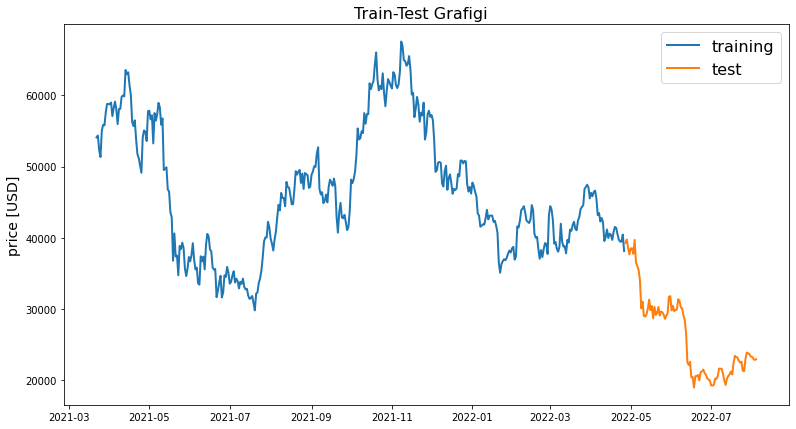

In [ ]:
line_plot(train[target_col], test[target_col], 'training', 'test', title='Train-Test Grafigi  ') #train ve test olarak ayirdigimiz verinin fiyat-tarih eksenlerinde grafiklestirilmesi.

In [ ]:
def normalise_zero_base(df): #pencerelere ayrilmis veriyi 0-1 arasinda normalize eden fonksiyon.
    return df / df.iloc[0] - 1

In [ ]:
def extract_window_data(df, window_len=5, zero_base=True): #veriyi pencerelere ayiran fonksiyon (ayni zamanda pencerelere ayrilan verilere normalise_zero_base fonksiyonu uygulaniyor).
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
          tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [ ]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.2): #veriyi train-test kisimlarina ayirir, ayrilan veriye normalise_zero_base() ve extract_window_data fonksiyonlarini uygular.
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

# **<font color='black'>LSTM Modelinin Oluşturulması ve Uygulanması </font>**


**<font color='black'>LSTM Nedir ? </font>**

<font color='grey'>Long Short-Term Memory (Uzun Kısa-Süreli Bellek) derin öğrenme alanında kullanılan yapay  bir Yinelemeli Sinir Ağı (RNN)  mimarisidir. Standart ileri beslemeli sinir ağlarının aksine, LSTM'nin geri bildirim bağlantıları vardır.  Her LSTM katmanının hem önceki katmanlardan hem de mevcut katmandan bilgi almasına izin vermek için özel kapılar kullanarak çalışır. Veri birden fazla kapıdan (forget gate (unut kapısı), input gate (giriş kapısı) vb.) ve çeşitli aktivasyon işlevlerinden (tanh işlevi, relu işlevi gibi) geçer ve LSTM hücrelerinden geçirilir. Bunun en büyük avantajı ise, her LSTM hücresinin belirli bir süre boyunca kalıpları hatırlamasını sağlamasıdır. Dikkat edilmesi gereken şey, LSTM'nin önemli bilgileri hatırlayabildiği ve aynı zamanda gereksiz bilgileri unutabildiğidir. LSTM mimarisi aşağıdaki şekilde gösterilmiştir.</font>




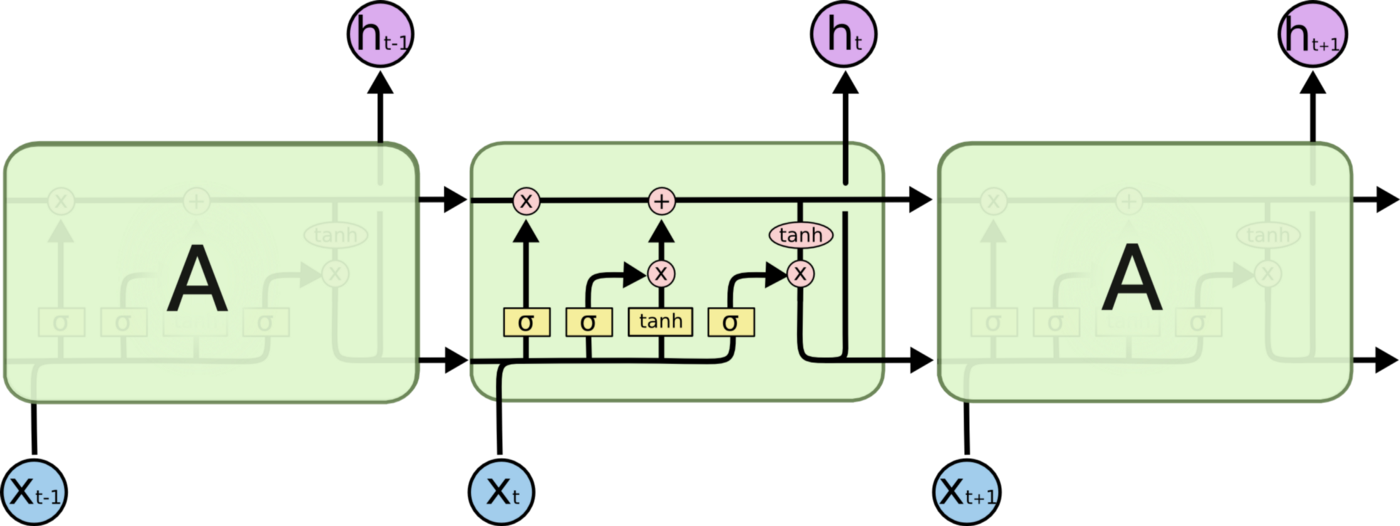

In [ ]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [ ]:
window_len = 5
test_size = 0.2
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [ ]:
train, test, X_train, X_test, y_train, y_test = prepare_data(data, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [ ]:
train

,high,low,open,volumefrom,volumeto,close
time,,,,,,
2021-03-22,58431.44,53795.78,57374.95,51098.90,2.865347e+09,54095.36
2021-03-23,55836.27,52984.36,54095.36,44780.24,2.444787e+09,54355.45
2021-03-24,57202.53,51685.15,54355.45,62596.16,3.420695e+09,52303.02
2021-03-25,53199.52,50406.31,52303.02,69776.36,3.617760e+09,51336.09
2021-03-26,55083.90,51275.54,51336.09,46165.63,2.461374e+09,55055.43
...,...,...,...,...,...,...
2022-04-22,40794.73,39190.22,40490.97,28863.91,1.154694e+09,39716.04
2022-04-23,39988.54,39305.67,39716.04,11481.51,4.556596e+08,39445.97
2022-04-24,39943.44,39044.29,39445.97,12668.56,5.012721e+08,39466.26


In [ ]:
test

,high,low,open,volumefrom,volumeto,close
time,,,,,,
2022-04-27,39465.62,37900.60,38117.39,34510.32,1.341341e+09,39252.04
2022-04-28,40386.50,38892.10,39252.04,29981.12,1.188928e+09,39749.75
2022-04-29,39922.60,38179.15,39749.75,24745.92,9.640201e+08,38594.22
2022-04-30,38788.01,37607.77,38594.22,13696.14,5.252913e+08,37650.13
2022-05-01,38668.00,37461.76,37650.13,17299.60,6.590303e+08,38480.53
...,...,...,...,...,...,...
2022-07-31,24187.18,23243.11,23646.03,23010.79,5.454065e+08,23308.14
2022-08-01,23504.29,22866.94,23308.14,31489.52,7.303424e+08,23271.57
2022-08-02,23451.58,22668.87,23271.57,34258.27,7.876981e+08,22991.49


In [ ]:
X_train.shape

(396, 5, 6)

In [ ]:
X_test.shape

(95, 5, 6)

In [ ]:
y_train.shape

(396,)

In [ ]:
y_test.shape

(95,)

In [ ]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Epoch 1/20
13/13 [==============================] - 5s 95ms/step - loss: 0.0085 - val_loss: 0.0076
Epoch 2/20
13/13 [==============================] - 0s 18ms/step - loss: 0.0053 - val_loss: 0.0043
Epoch 3/20
13/13 [==============================] - 0s 19ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 4/20
13/13 [==============================] - 0s 14ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 5/20
13/13 [==============================] - 0s 17ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 6/20
13/13 [==============================] - 0s 14ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 7/20
13/13 [==============================] - 0s 17ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 8/20
13/13 [==============================] - 0s 21ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 9/20
13/13 [==============================] - 0s 21ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 10/20
13/13 [==============================] - 0s 23ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 11/

# **<font color='black'>Tahmin Sonuçlarını Görselleştirme ve Başarı Metriklerinin Değerlendirilmesi</font>**

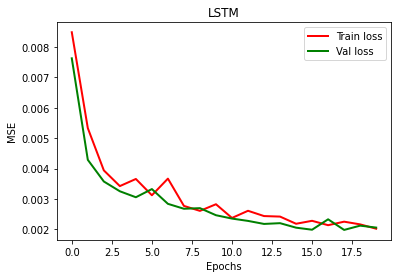

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.legend()
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Val loss')
plt.legend()
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

<font color='grey'>Mean Absolute Error (MAE): MAE (Ortalama Mutlak Hata), tahmin edilen değerler ile gerçek değerler arasındaki farktır. Tam olarak ifade etmek gerekirse, veri kümesinin tüm örneğinde, o örnek için gerçek değer ile öngörülen değer arasındaki her bir farkın mutlak değerinin ortalamasıdır. Düşük bir değer daha iyi doğruluğu gösterir.</font>

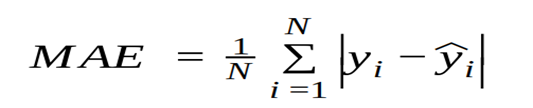

In [ ]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
mean_absolute_error(preds, y_test)

0.03521891007894016

<font color='grey'>Mean Squared Error (MSE): MSE (Ortalama Kare Hatası) en sık kullanılan regresyon kaybı fonksiyonudur. MSE, tüm veri kümesinde örnek başına ortalama kare kaybıdır. MSE’yi hesaplamak için, tek tek örnekler için tüm kare kayıpları toplanıp ve daha sonra örnek sayısına bölünür. Düşük bir değer daha iyi doğruluğu gösterir. Kare nedeniyle, büyük hataların MSE üzerinde küçük hatalardan daha fazla etkisi vardır. Bu nedenle MAE, kareden faydalanmadığı için aykırı değerlere karşı daha sağlamdır.</font>

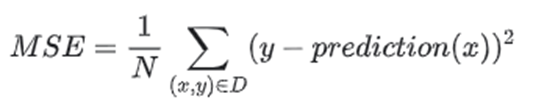

In [ ]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE

0.0020614459734964617

<font color='grey'>R² (R-Squared): R², verilerin yerleştirilmiş regresyon hattına ne kadar yakın olduğunun istatistiksel bir ölçüsüdür. Ayrıca belirleme katsayısı veya çoklu regresyon için çoklu belirleme katsayısı olarak da bilinir. Daha basit bir dilde söylemek gerekirse R², doğrusal regresyon modelleri için uygunluk ölçüsüdür. Aynı veri seti için, daha yüksek R² değerleri, gözlemlenen veriler ve fit edilen değerler arasında daha küçük farkları temsil eder. Örneğin bazı çalışma alanları, doğası gereği daha fazla miktarda açıklanamayan varyasyona sahiptir. Bu alanlarda, R² değerleriniz daha düşük olmak zorundadır. Mesela insan davranışını açıklamaya çalışan çalışmalar genellikle % 50'nin altında R-kare değerlerine sahiptir. İnsanları tahmin etmek, fiziksel süreçler gibi şeylerden daha zordur.
</font>

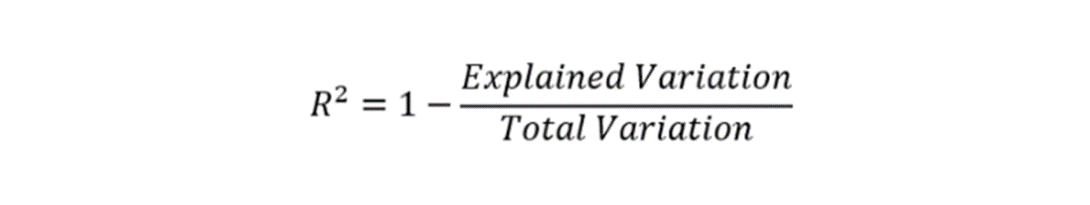

In [ ]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.7543640578159502

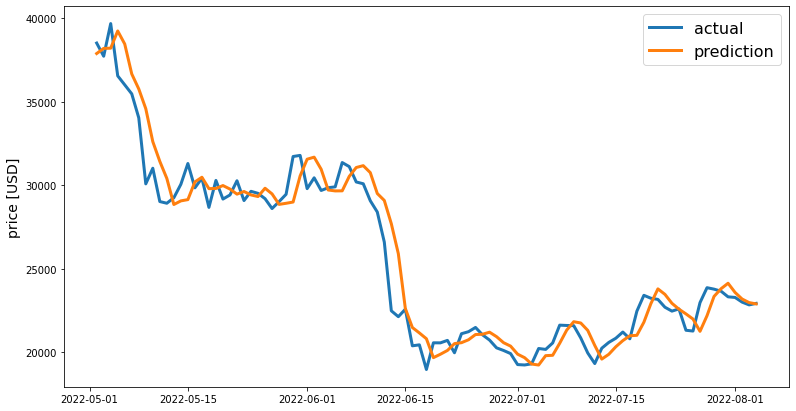

In [ ]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual', 'prediction', lw=3)

**<font color='red'>Soru : Model için R²’nin ne kadar yüksek olması yararlı tahminler üretir? Bu, ihtiyaç duyduğunuz hassasiyete ve verilerinizde bulunan varyasyon miktarına bağlıdır. Kesin tahminler için yüksek bir R-kare gereklidir ancak yüksek R² değerleri her zaman mükemmel mi?</font>**

**<font color='black'>Cevap : Hayır! Yüksek R² değerine sahip bir regresyon modelinde çok sayıda sorun olabilir. Örneğin, ‘overfitting’ durumunda yüksek R-kare değerlerine ulaşabilirsiniz.</font>**


In [ ]:
model.predict(X_test).squeeze()

array([-0.03480838, -0.03916197, -0.01006176,  0.04218557, -0.00065002,
       -0.04806112, -0.05201158, -0.12852296, -0.1077667 , -0.1273647 ,
       -0.14284371, -0.152607  , -0.03390926, -0.0606389 ,  0.04047096,
        0.05383569,  0.01865776, -0.00833429, -0.04219165, -0.00244113,
       -0.03141715,  0.03323825, -0.02872254,  0.00517744,  0.01376656,
       -0.02609643, -0.007851  , -0.0242157 , -0.01762054,  0.04663128,
        0.1033907 ,  0.09178507,  0.05091658, -0.06328075, -0.06694649,
       -0.00439319,  0.0027526 ,  0.04639229,  0.04427993,  0.02852504,
       -0.05916475, -0.06521301, -0.08288478, -0.13931534, -0.22237806,
       -0.24371123, -0.20472038, -0.07447958, -0.11089299, -0.11952465,
       -0.01355574,  0.00356752,  0.08478402,  0.0088487 ,  0.02422273,
        0.01773506,  0.061826  , -0.00840059, -0.03102208, -0.05210603,
       -0.05504362, -0.0510101 , -0.047887  , -0.04336585, -0.00626128,
        0.02892527,  0.06763966,  0.10466876,  0.07939702,  0.07

In [1]:
!git config --global user.email "goktuggokmen.gg@gmail.com"
!git config --global user.name "goktuggokmen"

In [5]:
!git clone https://github.com/goktuggokmen/Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning.git
%cd Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning

Cloning into 'Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning'...
/content/Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning/Applications-of-Digital-Signal-Processing-Cryptocurrency-Price-Prediction-Using-Deep-Learning


In [6]:
!git add .
!git commit -m "Initial commit"

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
